### 26. Segmentation of 3D lung CTs using MONAI and Elastix

This notebook uses the MONAI code and pretrained model from the [paired lung CT registration tutorial](https://github.com/Project-MONAI/tutorials/blob/main/3d_registration/paired_lung_ct.ipynb) to register an inspiration CT to an expiration CT of the same patient. It then refines the deep learning result with a non-linear Elastix registration, which takes the dense displacement field (DDF) predicted by MONAI as its initial transform. The lung masks, warped with each result, measure the improvement.

In [1]:
import os

import itk
import matplotlib.pyplot as plt
import numpy as np
import torch
from monai.apps import download_and_extract, download_url
from monai.data import Dataset, itk_torch_bridge
from monai.metrics import DiceMetric
from monai.networks.blocks import Warp
from monai.networks.nets import LocalNet
from monai.transforms import (
    Compose,
    LoadImaged,
    Resized,
    ScaleIntensityRanged,
)
from monai.utils import set_determinism

set_determinism(42)
if torch.cuda.is_available():
    device = "cuda:0"
else:
    device = "cpu"

print("Device: ", device)

Device:  cpu


### Dataset

Download and extract the dataset

In [2]:
root_dir = "./"
resource = "https://zenodo.org/records/3835682/files/training.zip"

compressed_file = os.path.join(root_dir, "paired_ct_lung.zip")
data_dir = os.path.join(root_dir, "paired_ct_lung")
if not os.path.exists(data_dir):
    download_and_extract(resource, compressed_file, root_dir)
    os.rename(os.path.join(root_dir, "training"), data_dir)

Split in training and validation. The pretrained model was trained on the first 18 pairs.

In [3]:
data_dicts = [
    {
        "fixed_image": os.path.join(data_dir, "scans/case_%03d_exp.nii.gz" % idx),
        "moving_image": os.path.join(data_dir, "scans/case_%03d_insp.nii.gz" % idx),
        "fixed_label": os.path.join(data_dir, "lungMasks/case_%03d_exp.nii.gz" % idx),
        "moving_label": os.path.join(data_dir, "lungMasks/case_%03d_insp.nii.gz" % idx),
    }
    for idx in range(1, 21)
]

train_files, val_files = data_dicts[:18], data_dicts[18:]

Since we are going to use the pretrained model, we only need the validation transforms, which match the preprocessing the model was trained with.

In [4]:
val_transforms = Compose(
    [
        LoadImaged(
            keys=["fixed_image", "moving_image", "fixed_label", "moving_label"],
            ensure_channel_first=True,
        ),
        ScaleIntensityRanged(
            keys=["fixed_image", "moving_image"],
            a_min=-285,
            a_max=3770,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
        Resized(
            keys=["fixed_image", "moving_image", "fixed_label", "moving_label"],
            mode=("trilinear", "trilinear", "nearest", "nearest"),
            align_corners=(True, True, None, None),
            spatial_size=(96, 96, 104),
        ),
    ]
)

Load the first validation pair. Each item is a MONAI `MetaTensor`, which keeps the image affine updated by the resizing.

In [5]:
val_dataset = Dataset(data=val_files, transform=val_transforms)
data = val_dataset[0]

### MONAI model with pre-trained weights

In [6]:
model = LocalNet(
    spatial_dims=3,
    in_channels=2,
    out_channels=3,
    num_channel_initial=32,
    extract_levels=[3],
    out_activation=None,
    out_kernel_initializer="zeros",
).to(device)
warp_layer = Warp().to(device)

monai.networks.blocks.Warp: Using PyTorch native grid_sample.


In [7]:
resource = "https://github.com/Project-MONAI/MONAI-extra-test-data/releases/download/0.8.1/pair_lung_ct.pth"
dst = os.path.join(root_dir, "pretrained_weight.pth")
download_url(resource, dst)
model.load_state_dict(torch.load(dst, map_location=device))
model.eval();

2026-09-30 16:40:30,396 - INFO - File exists: pretrained_weight.pth, skipped downloading.


No hash value provided for pretrained_weight.pth; file integrity is NOT verified.


In [8]:
with torch.no_grad():
    # Add a batch dimension and move the images to the device
    fixed_image = data["fixed_image"].unsqueeze(0).to(device)
    moving_image = data["moving_image"].unsqueeze(0).to(device)
    moving_label = data["moving_label"].unsqueeze(0).to(device)

    # Predict the DDF with LocalNet
    ddf = model(torch.cat((moving_image, fixed_image), dim=1))

    # Warp the moving image and label with the predicted DDF
    predicted_image_monai = warp_layer(moving_image, ddf)
    predicted_label_monai = warp_layer(moving_label, ddf)

    # Convert the label to [0, 1] and uint8
    predicted_label_monai = (predicted_label_monai > 0.5).to(torch.uint8)

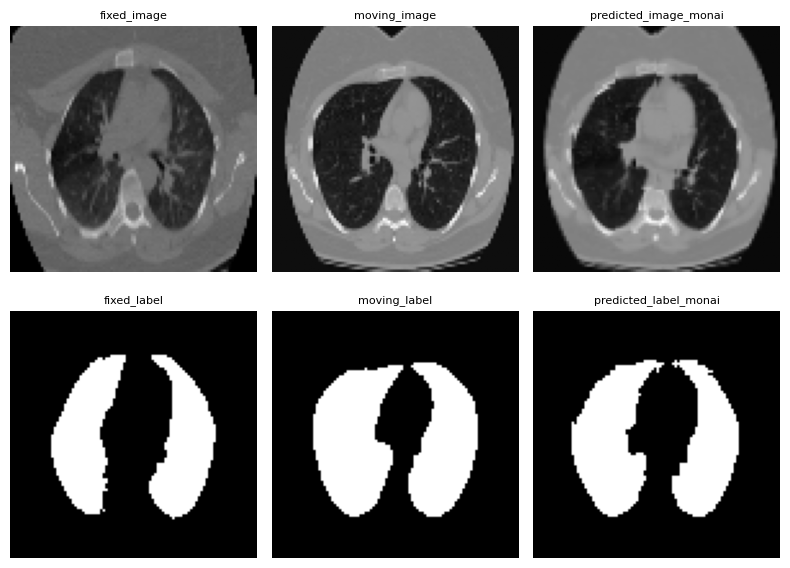

In [9]:
# Keep the images as NumPy arrays in MONAI's (x, y, z) axis order for visualization and evaluation
_to_array = lambda x: x.squeeze().cpu().numpy()
image_dict = {
    "fixed_image": _to_array(data["fixed_image"]),
    "fixed_label": _to_array(data["fixed_label"]),
    "moving_image": _to_array(data["moving_image"]),
    "moving_label": _to_array(data["moving_label"]),
    "predicted_image_monai": _to_array(predicted_image_monai),
    "predicted_label_monai": _to_array(predicted_label_monai),
}


def visualize_images(image_dict):
    keys = list(image_dict.keys())
    keys = keys[::2] + keys[1::2]  # re-arrange images vs labels
    central_slice = 52
    plt.figure(figsize=(8, 6))
    for i, key in enumerate(keys):
        plt.subplot(2, len(keys) // 2, i + 1)
        plt.title(key, fontsize=8)
        plt.imshow(image_dict[key][:, :, central_slice].T, cmap="gray")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


visualize_images(image_dict)

### Convert the MONAI images and displacement field to ITK

`monai.data.itk_torch_bridge` converts between MONAI and ITK. `metatensor_to_itk_image` transposes the MONAI array to ITK's axis order and sets the spacing, origin and direction from the `MetaTensor` affine, so Elastix registers the images in physical space.

In [10]:
fixed_image_itk = itk_torch_bridge.metatensor_to_itk_image(data["fixed_image"])
moving_image_itk = itk_torch_bridge.metatensor_to_itk_image(data["moving_image"])
moving_label_itk = itk_torch_bridge.metatensor_to_itk_image(
    data["moving_label"], dtype=np.uint8
)

# Resized aligns the corners of the images but not of the labels, which shifts the label
# affine by a fraction of a voxel. MONAI warps the label on the image grid, so use the
# image geometry for the label as well.
moving_label_itk.CopyInformation(moving_image_itk)

print("Size:", itk.size(fixed_image_itk))
print("Spacing:", itk.spacing(fixed_image_itk))

Size: itkSize3 ([96, 96, 104])
Spacing: itkVectorD3 ([3.51842, 2.51316, 3.51699])


MONAI's DDF has one channel per array axis, in voxels, and maps each fixed image voxel to the moving image. An ITK `DisplacementFieldTransform` has the same direction, from the fixed to the moving image, in physical units. `monai_to_itk_ddf` expects the DDF laid out like an ITK array, (z, y, x), for both the channels and the grid, so reverse the MONAI (x, y, z) order first.

In [11]:
# Copy, because monai_to_itk_ddf scales the array in place
ddf_zyx = ddf.squeeze(0).cpu().numpy()[::-1].transpose(0, 3, 2, 1).copy()
displacement_field = itk_torch_bridge.monai_to_itk_ddf(fixed_image_itk, ddf_zyx)

# The Elastix initial transform needs double precision
displacement_field_d = itk.image_from_array(
    np.asarray(displacement_field, dtype=np.float64), is_vector=True
)
displacement_field_d.CopyInformation(displacement_field)

monai_transform = itk.DisplacementFieldTransform[itk.D, 3].New()
monai_transform.SetDisplacementField(displacement_field_d)

Check the conversion: resampling the moving image with the ITK transform reproduces MONAI's warp.

In [12]:
resampled_image_itk = itk.resample_image_filter(
    moving_image_itk,
    transform=monai_transform,
    use_reference_image=True,
    reference_image=fixed_image_itk,
)
difference = np.abs(
    np.asarray(resampled_image_itk).T - image_dict["predicted_image_monai"]
)
print(f"Mean absolute difference from the MONAI warp: {difference.mean():.4f}")
assert difference.mean() < 0.01

Mean absolute difference from the MONAI warp: 0.0048


### Refine using Elastix

First, create a mask for the fixed image since it is cropped compared to the moving

In [13]:
fixed_array = itk.array_view_from_image(fixed_image_itk)
fixed_mask_itk = itk.image_from_array(
    (fixed_array > 1.05 * fixed_array.min()).astype(np.uint8)
)
fixed_mask_itk.CopyInformation(fixed_image_itk)

Pass the MONAI transform as `external_initial_transform`. Elastix composes it with the B-spline transform it optimizes, so the moving image is resampled only once. Elastix evaluates an external transform only at points, so use the image similarity metric without the default bending energy penalty, which needs the spatial derivatives of the whole transform. The final B-spline grid spacing is in physical units, 12 mm.

In [14]:
parameter_object = itk.ParameterObject()
bspline_parameter_map = parameter_object.GetDefaultParameterMap("bspline", 1, 12.0)
bspline_parameter_map["Metric"] = ["AdvancedMattesMutualInformation"]
parameter_object.AddParameterMap(bspline_parameter_map)

result_image, result_transform_parameters = itk.elastix_registration_method(
    fixed_image_itk,
    moving_image_itk,
    fixed_mask=fixed_mask_itk,
    parameter_object=parameter_object,
    external_initial_transform=monai_transform,
    log_to_console=False,
)

The resulting transform parameter object holds the MONAI transform followed by the B-spline transform. Transformix applies both to the moving label, with nearest neighbor interpolation.

In [15]:
result_transform_parameters.SetParameter("FinalBSplineInterpolationOrder", "0")

predicted_label_elastix_itk = itk.transformix_filter(
    moving_label_itk,
    transform_parameter_object=result_transform_parameters,
    log_to_console=False,
)

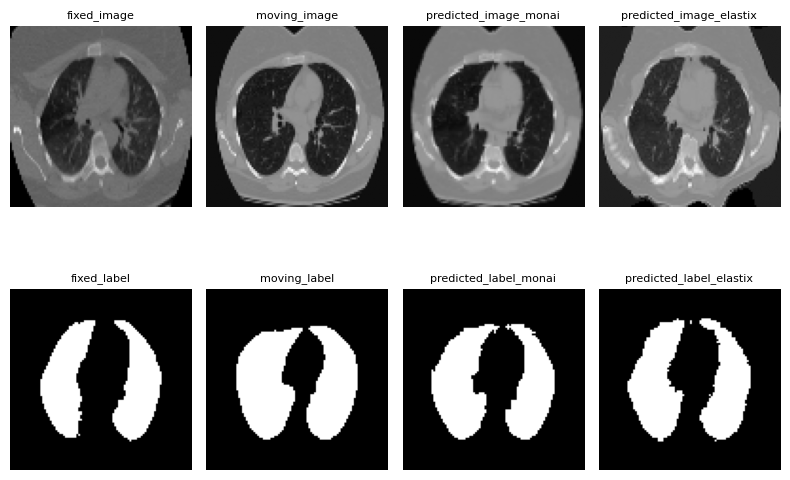

In [16]:
# Append to the image dictionary, transposing from ITK's axis order back to MONAI's
image_dict["predicted_image_elastix"] = np.asarray(result_image).T
image_dict["predicted_label_elastix"] = np.asarray(predicted_label_elastix_itk).T

visualize_images(image_dict)

### Compare the Dice score on the labels

In [17]:
dice_metric = DiceMetric(include_background=True, reduction="mean")

_to_tensor = lambda x: torch.as_tensor(x.astype(np.float32))[None, None]
fixed_label = _to_tensor(image_dict["fixed_label"])
dice_moving = dice_metric(_to_tensor(image_dict["moving_label"]), fixed_label).item()
dice_monai = dice_metric(
    _to_tensor(image_dict["predicted_label_monai"]), fixed_label
).item()
dice_monai_elastix = dice_metric(
    _to_tensor(image_dict["predicted_label_elastix"]), fixed_label
).item()

print(f"Dice moving: {dice_moving:.4f}")
print(f"Dice monai: {dice_monai:.4f}")
print(f"Dice monai+elastix: {dice_monai_elastix:.4f}")
assert dice_moving < dice_monai < dice_monai_elastix

Dice moving: 0.7347
Dice monai: 0.8892
Dice monai+elastix: 0.9201


### Conclusion

The pretrained MONAI network aligns the lungs in a single forward pass. The Elastix B-spline registration, initialized with the MONAI displacement field, further improves the overlap of the lung masks. Since the Elastix result includes the MONAI transform, transformix warps the label with the combined transform in a single resampling step.